In [40]:
!pip install yfinance


In [41]:

# ============================================================
# CELL 1 — IMPORTS & GLOBAL CONFIGURATION
# NIFTY Buy-Put EMA Pullback Strategy
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
from   matplotlib.gridspec import GridSpec
import os, pathlib

# ── Display settings ────────────────────────────────────────
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (16, 6)})

# ── Global constants ─────────────────────────────────────────
TICKER           = "^NSEI"          # NIFTY 50
INTERVAL         = "5m"
LOOKBACK_DAYS    = 59               # yfinance max for 5-min = 60 days

SESSION_START    = "09:30"
SESSION_END      = "14:45"

EMA_FAST         = 20
EMA_SLOW         = 200

TOUCH_BUFFER     = 10               # points: invalid if close > EMA20 + 10
SL_BUFFER        = 5                # extra points above EMA20 for SL
RISK_REWARD      = 2.5              # minimum RR
TRAIL_TRIGGER_R  = 1.5              # start trailing after 1.5 R

CAPITAL          = 100_000          # ₹ starting capital
RISK_PCT         = 0.01             # 1% per trade

# ── Output folder (works on Colab /content  AND  local Windows path) ────
try:
    import google.colab  # noqa
    WORKSPACE = "/content"
except ImportError:
    WORKSPACE = str(pathlib.Path(__file__).parent) if "__file__" in dir() \
                else str(pathlib.Path.cwd())

print("✅ Configuration loaded.")
print(f"   Ticker   : {TICKER}  |  Interval : {INTERVAL}  |  Lookback : {LOOKBACK_DAYS} days")
print(f"   EMA      : {EMA_FAST} / {EMA_SLOW}")
print(f"   Session  : {SESSION_START} ➜ {SESSION_END}")
print(f"   Capital  : ₹{CAPITAL:,}  |  Risk/trade : {RISK_PCT*100:.0f}%")
print(f"   Output   : {WORKSPACE}")


✅ Configuration loaded.
   Ticker   : ^NSEI  |  Interval : 5m  |  Lookback : 59 days
   EMA      : 20 / 200
   Session  : 09:30 ➜ 14:45
   Capital  : ₹100,000  |  Risk/trade : 1%
   Output   : /content


In [42]:

# ============================================================
# CELL 2 — DATA ENGINE
# Fetch 5-min NIFTY OHLCV and apply session filter
# ============================================================

def fetch_data(ticker: str = TICKER,
               interval: str = INTERVAL,
               lookback_days: int = LOOKBACK_DAYS) -> pd.DataFrame:
    """Download OHLCV data from yfinance and normalise columns."""
    print(f"⏳ Fetching {ticker}  [{interval}]  last {lookback_days} days …")

    raw = yf.download(
        tickers     = ticker,
        period      = f"{lookback_days}d",
        interval    = interval,
        auto_adjust = True,
        progress    = False,
    )

    if raw.empty:
        raise ValueError("yfinance returned empty DataFrame. Check ticker / interval.")

    # ── Flatten MultiIndex columns if present (yfinance ≥ 0.2) ──────────
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [col[0] for col in raw.columns]

    df = raw.rename(columns=str.lower).copy()
    df.index = pd.to_datetime(df.index)

    # ── Localise to IST ──────────────────────────────────────────────────
    if df.index.tz is not None:
        df.index = df.index.tz_convert("Asia/Kolkata")
    else:
        df.index = df.index.tz_localize("UTC").tz_convert("Asia/Kolkata")

    df.sort_index(inplace=True)
    df.dropna(subset=["close"], inplace=True)

    print(f"   Rows fetched  : {len(df):,}")
    print(f"   Date range    : {df.index[0].date()}  →  {df.index[-1].date()}")
    return df


def apply_session_filter(df: pd.DataFrame,
                          start: str = SESSION_START,
                          end:   str = SESSION_END) -> pd.DataFrame:
    """Keep only candles within the allowed trading session."""
    t = df.index.time
    s = pd.Timestamp(f"2000-01-01 {start}").time()
    e = pd.Timestamp(f"2000-01-01 {end}").time()
    mask = (t >= s) & (t <= e)
    filtered = df.loc[mask].copy()
    print(f"   Session rows  : {len(filtered):,}  "
          f"(filtered from {len(df):,}  |  window {start}–{end})")
    return filtered


# ── Run ──────────────────────────────────────────────────────
raw_df     = fetch_data()
session_df = apply_session_filter(raw_df)
print("\n✅ Data ready.")
session_df.tail(3)


⏳ Fetching ^NSEI  [5m]  last 59 days …
   Rows fetched  : 4,254
   Date range    : 2025-12-18  →  2026-03-13
   Session rows  : 3,627  (filtered from 4,254  |  window 09:30–14:45)

✅ Data ready.


,close,high,low,open,volume
Datetime,,,,,
2026-03-13 14:35:00+05:30,23208.65,23249.05,23208.30,23242.10,0
2026-03-13 14:40:00+05:30,23224.80,23231.55,23205.65,23211.75,0
2026-03-13 14:45:00+05:30,23191.05,23231.20,23177.55,23228.70,0


In [43]:
session_df.head()

,close,high,low,open,volume
Datetime,,,,,
2025-12-18 09:30:00+05:30,25785.30,25795.45,25774.90,25780.15,0
2025-12-18 09:35:00+05:30,25774.55,25787.60,25770.80,25785.85,0
2025-12-18 09:40:00+05:30,25745.10,25776.85,25743.45,25776.10,0
2025-12-18 09:45:00+05:30,25740.75,25747.75,25726.75,25745.10,0
2025-12-18 09:50:00+05:30,25750.25,25752.60,25734.65,25741.05,0


In [44]:

# ============================================================
# CELL 3 — INDICATOR ENGINE
# EMA-20, EMA-200  (no look-ahead, pandas ewm)
# ============================================================

def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute EMA-20 and EMA-200 using pandas ewm (min_periods=full span
    to avoid NaN pollution at the start).
    All calculations are purely backward-looking — zero look-ahead.
    """
    out = df.copy()

    out["ema20"]  = out["close"].ewm(span=EMA_FAST,  adjust=False,
                                     min_periods=EMA_FAST).mean()
    out["ema200"] = out["close"].ewm(span=EMA_SLOW, adjust=False,
                                     min_periods=EMA_SLOW).mean()

    # Convenience booleans (vectorised)
    out["below_ema20"]  = out["close"] < out["ema20"]
    out["below_ema200"] = out["close"] < out["ema200"]

    # Candle body direction
    out["bearish_candle"] = out["close"] < out["open"]
    out["bullish_candle"] = out["close"] > out["open"]

    # Candle body / wick sizes (useful for debug)
    out["body"]       = (out["close"] - out["open"]).abs()
    out["upper_wick"] = out["high"] - out[["open", "close"]].max(axis=1)
    out["lower_wick"] = out[["open", "close"]].min(axis=1) - out["low"]

    out.dropna(subset=["ema200"], inplace=True)
    print(f"✅ Indicators computed.  {len(out):,} rows after EMA-{EMA_SLOW} warmup.")
    return out


indicator_df = add_indicators(session_df)
indicator_df[["close", "ema20", "ema200",
              "below_ema20", "below_ema200", "bearish_candle"]].tail(5)


✅ Indicators computed.  3,428 rows after EMA-200 warmup.


,close,ema20,ema200,below_ema20,below_ema200,bearish_candle
Datetime,,,,,,
2026-03-13 14:25:00+05:30,23202.50,23197.23,23637.75,False,True,True
2026-03-13 14:30:00+05:30,23235.50,23200.88,23633.75,False,True,False
2026-03-13 14:35:00+05:30,23208.65,23201.62,23629.52,False,True,True
2026-03-13 14:40:00+05:30,23224.80,23203.82,23625.49,False,True,False
2026-03-13 14:45:00+05:30,23191.05,23202.61,23621.17,True,True,True


In [45]:

# ============================================================
# CELL 4 — SIGNAL ENGINE
# Vectorised logic — replicates every rule from the strategy doc
# ============================================================

def generate_signals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rules implemented:
    ──────────────────────────────────────────────────────────
    TREND FILTER (both must be True):
        close < EMA20   AND   close < EMA200
        ❌ NO TRADE if price is between EMA20 and EMA200

    PULLBACK DETECTION (on current candle):
        The candle's high touched OR came within TOUCH_BUFFER points
        of EMA20 from below.
        i.e.  high >= EMA20 - TOUCH_BUFFER
        (price pulled back up toward EMA20 inside a downtrend)

    ENTRY TRIGGER (bearish rejection):
        A.  close < EMA20  (closes back below EMA20)
        B.  close <= EMA20 + TOUCH_BUFFER  (wick rejection — not 10+ pts above)
        C.  bearish_candle  (close < open)
        ❌ REJECT if close > EMA20 + TOUCH_BUFFER

    Combined signal = TREND & PULLBACK & ENTRY
    ──────────────────────────────────────────────────────────
    NOTE: Signals reference only current-bar and PREVIOUS-bar data
          → strictly NO look-ahead.
    """
    out = df.copy()

    # ── 1. Trend confirmation ────────────────────────────────
    #    Price must be below BOTH EMAs
    trend_bear = out["below_ema20"] & out["below_ema200"]

    # Extra safety: reject candles where price is sandwiched between the two EMAs
    between_emas      = (out["close"] > out["ema20"]) & (out["close"] < out["ema200"])
    trend_confirmed   = trend_bear & ~between_emas

    # Added filter: require EMA gap to be > 20 points
    ema_gap_ok = (out["ema200"] - out["ema20"]) > 20

    # ── 2. Pullback detection ────────────────────────────────
    #    The high of the PREVIOUS candle (or current) reached up toward EMA20.
    #    We look back up to 3 candles to catch multi-bar pullbacks.
    touched_ema20_cur  = out["high"] >= out["ema20"] - TOUCH_BUFFER
    touched_ema20_p1   = out["high"].shift(1) >= out["ema20"].shift(1) - TOUCH_BUFFER
    touched_ema20_p2   = out["high"].shift(2) >= out["ema20"].shift(2) - TOUCH_BUFFER

    pullback = touched_ema20_cur | touched_ema20_p1 | touched_ema20_p2

    # ── 3. Entry trigger ─────────────────────────────────────
    #    Bearish candle that closes AT or BELOW EMA20
    #    Reject if close is more than TOUCH_BUFFER (10 pts) ABOVE EMA20
    entry_close_valid = out["close"] <= out["ema20"] + TOUCH_BUFFER
    close_below_ema20  = out["close"] < out["ema20"]   # strongest form
    entry_trigger      = out["bearish_candle"] & entry_close_valid & close_below_ema20

    # ── 4. Combined raw signal ───────────────────────────────
    out["signal"] = trend_confirmed & ema_gap_ok & pullback & entry_trigger

    # ── 5. Remove consecutive signals (take first only) ──────
    #    Once a trade is open, suppress further signals until the next trade.
    #    This is handled in the backtest engine (stateful loop),
    #    but we pre-tag raw signals here.
    out["raw_signal"] = out["signal"].astype(int)

    n = out["signal"].sum()
    print(f"✅ Signal engine done.  Raw signals : {n}  over {len(out):,} bars.")
    return out


signal_df = generate_signals(indicator_df)
signal_df[signal_df["signal"]][["close", "ema20", "ema200",
                                 "bearish_candle", "signal"]].head(10)


✅ Signal engine done.  Raw signals : 451  over 3,428 bars.


,close,ema20,ema200,bearish_candle,signal
Datetime,,,,,
2025-12-26 10:45:00+05:30,26089.60,26103.98,26127.85,True,True
2025-12-26 10:55:00+05:30,26089.40,26101.46,26127.10,True,True
2025-12-26 11:00:00+05:30,26087.75,26100.15,26126.71,True,True
2025-12-26 11:05:00+05:30,26078.45,26098.08,26126.23,True,True
2025-12-26 11:10:00+05:30,26072.80,26095.68,26125.70,True,True
2025-12-26 11:15:00+05:30,26064.50,26092.71,26125.09,True,True
2025-12-26 12:00:00+05:30,26054.45,26071.03,26119.22,True,True
2025-12-26 12:20:00+05:30,26058.20,26067.67,26116.93,True,True
2025-12-26 12:30:00+05:30,26045.90,26064.90,26115.66,True,True


In [46]:
signal_df

,close,high,low,open,volume,ema20,ema200,below_ema20,below_ema200,bearish_candle,bullish_candle,body,upper_wick,lower_wick,signal,raw_signal
Datetime,,,,,,,,,,,,,,,,
2025-12-23 10:05:00+05:30,26186.75,26188.25,26178.70,26181.65,0,26154.54,26013.81,False,False,False,True,5.10,1.50,2.95,False,0
2025-12-23 10:10:00+05:30,26184.20,26196.60,26183.55,26186.45,0,26157.36,26015.51,False,False,True,False,2.25,10.15,0.65,False,0
2025-12-23 10:15:00+05:30,26169.65,26186.40,26168.75,26184.65,0,26158.53,26017.04,False,False,True,False,15.00,1.75,0.90,False,0
2025-12-23 10:20:00+05:30,26166.55,26170.50,26163.40,26170.00,0,26159.30,26018.53,False,False,True,False,3.45,0.50,3.15,False,0
2025-12-23 10:25:00+05:30,26172.10,26175.45,26163.30,26167.15,0,26160.52,26020.06,False,False,False,True,4.95,3.35,3.85,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-13 14:25:00+05:30,23202.50,23225.10,23199.75,23210.80,0,23197.23,23637.75,False,True,True,False,8.30,14.30,2.75,False,0
2026-03-13 14:30:00+05:30,23235.50,23258.60,23203.60,23204.60,0,23200.88,23633.75,False,True,False,True,30.90,23.10,1.00,False,0
2026-03-13 14:35:00+05:30,23208.65,23249.05,23208.30,23242.10,0,23201.62,23629.52,False,True,True,False,33.45,6.95,0.35,False,0


In [47]:

# ============================================================
# CELL 5 — RISK ENGINE
# Position sizing, SL placement, Target calculation
# ============================================================

def calculate_sl(entry_price: float, ema20_at_entry: float) -> float:
    """
    SL = EMA20 + SL_BUFFER (dynamic, above EMA20 resistance).
    For a PUT trade, we lose if price goes UP (PUT value declines).
    """
    return round(ema20_at_entry + SL_BUFFER, 2)


def calculate_target(entry_price: float, sl: float,
                     rr: float = RISK_REWARD) -> float:
    """
    Target = Entry - (SL - Entry) * RR   [price moves DOWN for profit]
    """
    risk   = sl - entry_price          # positive number (SL above entry)
    target = entry_price - risk * rr
    return round(target, 2)


def calculate_position_size(entry_price: float, sl: float,
                             capital: float = CAPITAL,
                             risk_pct: float = RISK_PCT) -> float:
    """
    Lot size (index units / notional qty):
        risk_amount = capital * risk_pct
        sl_points   = sl - entry_price
        qty         = risk_amount / sl_points
    """
    risk_amount = capital * risk_pct
    sl_points   = abs(sl - entry_price)
    if sl_points < 0.01:
        return 0.0
    qty = risk_amount / sl_points
    return round(qty, 4)


def risk_snapshot(entry: float, ema20: float, capital: float = CAPITAL) -> dict:
    """Return a full risk snapshot for one trade."""
    sl     = calculate_sl(entry, ema20)
    target = calculate_target(entry, sl)
    qty    = calculate_position_size(entry, sl, capital)
    risk   = abs(sl - entry)
    return {
        "entry"    : entry,
        "sl"       : sl,
        "target"   : target,
        "risk_pts" : round(risk, 2),
        "reward_pts": round(risk * RISK_REWARD, 2),
        "qty"      : qty,
        "risk_₹"   : round(qty * risk, 2),
    }


# ── Quick demonstration ──────────────────────────────────────
_sample_close = signal_df.loc[signal_df["signal"], "close"].iloc[0]  \
                if signal_df["signal"].any() else 22000.0
_sample_ema20 = signal_df.loc[signal_df["signal"], "ema20"].iloc[0]  \
                if signal_df["signal"].any() else 22020.0

snap  = risk_snapshot(_sample_close, _sample_ema20)
print("✅ Risk Engine ready.\n")
print("── Sample Trade Risk Snapshot ──────────────────────────")
for k, v in snap.items():
    print(f"   {k:<12} : {v}")


✅ Risk Engine ready.

── Sample Trade Risk Snapshot ──────────────────────────
   entry        : 26089.599609375
   sl           : 26108.98
   target       : 26041.15
   risk_pts     : 19.38
   reward_pts   : 48.45
   qty          : 51.5985
   risk_₹       : 1000.0


In [48]:
rows= signal_df.reset_index()   # rows[i] → dict-like access, .name = iloc index
rows["Datetime"]

,Datetime
0,2025-12-23 10:05:00+05:30
1,2025-12-23 10:10:00+05:30
2,2025-12-23 10:15:00+05:30
3,2025-12-23 10:20:00+05:30
4,2025-12-23 10:25:00+05:30
...,...
3423,2026-03-13 14:25:00+05:30
3424,2026-03-13 14:30:00+05:30
3425,2026-03-13 14:35:00+05:30
3426,2026-03-13 14:40:00+05:30


In [49]:

# ============================================================
# CELL 6 — BACKTEST ENGINE
# Event-driven bar-by-bar simulation (no look-ahead)
# Handles: entry, SL, target, 1.5R trail, EOD exit
# ============================================================

def run_backtest(df: pd.DataFrame,
                 capital: float = CAPITAL,
                 risk_pct: float = RISK_PCT) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns
    -------
    trades_df  : one row per completed trade
    equity_df  : bar-by-bar equity curve
    """

    trades  = []         # list of completed trade dicts
    equity  = []         # list of (timestamp, equity_value)
    current = capital    # running capital

    # Trade-state machine
    in_trade      = False
    entry_price   = 0.0
    sl            = 0.0
    target        = 0.0
    qty           = 0.0
    entry_time    = None
    trail_active  = False
    risk_pts      = 0.0

    rows = df.reset_index()   # rows[i] → dict-like access, .name = iloc index

    for i, row in rows.iterrows():

        bar_time  = row["Datetime"]
        bar_close = row["close"]
        bar_high  = row["high"]
        bar_low   = row["low"]
        bar_ema20 = row["ema20"]

        # ── Equity mark ──────────────────────────────────────
        if in_trade:
            # Unrealised PnL (PUT benefits when price falls)
            unrealised_pnl = (entry_price - bar_close) * qty
            equity.append({"time": bar_time,
                            "equity": round(current + unrealised_pnl, 2)})
        else:
            equity.append({"time": bar_time, "equity": round(current, 2)})

        # ── Manage open trade ────────────────────────────────
        if in_trade:

            pnl_pts = entry_price - bar_close   # positive = profit (PUT)

            # ── Activate trailing at 1.5R ───────────────────
            if not trail_active and pnl_pts >= TRAIL_TRIGGER_R * risk_pts:
                trail_active = True

            # ── Update trailing SL via EMA20 ─────────────────
            if trail_active:
                # New SL = EMA20 + buffer (price must stay below EMA20)
                new_sl = bar_ema20 + SL_BUFFER
                # Only TIGHTEN sl (sl can only move down for a short trade)
                if new_sl < sl:
                    sl = new_sl

            # ── Check for SL hit (high touches or exceeds SL) ─
            if bar_high >= sl:
                exit_price = sl
                pnl_pts    = entry_price - exit_price
                pnl_money  = pnl_pts * qty
                current   += pnl_money
                r_mult     = pnl_pts / risk_pts if risk_pts > 0 else 0

                trades.append({
                    "entry_time"  : entry_time,
                    "exit_time"   : bar_time,
                    "entry_price" : round(entry_price, 2),
                    "sl"          : round(sl, 2),
                    "target"      : round(target, 2),
                    "exit_price"  : round(exit_price, 2),
                    "qty"         : round(qty, 4),
                    "pnl_pts"     : round(pnl_pts, 2),
                    "pnl_₹"       : round(pnl_money, 2),
                    "r_multiple"  : round(r_mult, 2),
                    "result"      : "WIN" if pnl_money > 0 else "LOSS",
                    "exit_reason" : "SL",
                    "capital"     : round(current, 2),
                })
                in_trade = trail_active = False
                continue

            # ── Check for Target hit (low reaches target) ────
            if bar_low <= target:
                exit_price = target
                pnl_pts    = entry_price - exit_price
                pnl_money  = pnl_pts * qty
                current   += pnl_money
                r_mult     = pnl_pts / risk_pts if risk_pts > 0 else 0

                trades.append({
                    "entry_time"  : entry_time,
                    "exit_time"   : bar_time,
                    "entry_price" : round(entry_price, 2),
                    "sl"          : round(sl, 2),
                    "target"      : round(target, 2),
                    "exit_price"  : round(exit_price, 2),
                    "qty"         : round(qty, 4),
                    "pnl_pts"     : round(pnl_pts, 2),
                    "pnl_₹"       : round(pnl_money, 2),
                    "r_multiple"  : round(r_mult, 2),
                    "result"      : "WIN",
                    "exit_reason" : "TARGET",
                    "capital"     : round(current, 2),
                })
                in_trade = trail_active = False
                continue

            # ── EOD / session-end forced exit (2:45 PM) ──────
            if bar_time.strftime("%H:%M") >= SESSION_END:
                exit_price = bar_close
                pnl_pts    = entry_price - exit_price
                pnl_money  = pnl_pts * qty
                current   += pnl_money
                r_mult     = pnl_pts / risk_pts if risk_pts > 0 else 0

                trades.append({
                    "entry_time"  : entry_time,
                    "exit_time"   : bar_time,
                    "entry_price" : round(entry_price, 2),
                    "sl"          : round(sl, 2),
                    "target"      : round(target, 2),
                    "exit_price"  : round(exit_price, 2),
                    "qty"         : round(qty, 4),
                    "pnl_pts"     : round(pnl_pts, 2),
                    "pnl_₹"       : round(pnl_money, 2),
                    "r_multiple"  : round(r_mult, 2),
                    "result"      : "WIN" if pnl_money > 0 else "LOSS",
                    "exit_reason" : "EOD",
                    "capital"     : round(current, 2),
                })
                in_trade = trail_active = False
                continue

        # ── Check for new entry (only if not in trade) ───────
        if not in_trade and row["signal"]:
            entry_price  = bar_close
            sl           = calculate_sl(entry_price, bar_ema20)
            target       = calculate_target(entry_price, sl)
            risk_pts     = abs(sl - entry_price)

            if risk_pts < 0.5:          # degenerate — skip
                continue

            qty          = calculate_position_size(entry_price, sl, current)
            if qty <= 0:
                continue

            entry_time   = bar_time
            trail_active = False
            in_trade     = True

    # Force-close any trade still open at end of data
    if in_trade:
        last = rows.iloc[-1]
        exit_price  = last["close"]
        pnl_pts     = entry_price - exit_price
        pnl_money   = pnl_pts * qty
        current    += pnl_money
        r_mult      = pnl_pts / risk_pts if risk_pts > 0 else 0
        trades.append({
            "entry_time"  : entry_time,
            "exit_time"   : last["Datetime"],
            "entry_price" : round(entry_price, 2),
            "sl"          : round(sl, 2),
            "target"      : round(target, 2),
            "exit_price"  : round(exit_price, 2),
            "qty"         : round(qty, 4),
            "pnl_pts"     : round(pnl_pts, 2),
            "pnl_₹"       : round(pnl_money, 2),
            "r_multiple"  : round(r_mult, 2),
            "result"      : "WIN" if pnl_money > 0 else "LOSS",
            "exit_reason" : "FORCE_CLOSE",
            "capital"     : round(current, 2),
        })

    trades_df = pd.DataFrame(trades)
    equity_df = pd.DataFrame(equity).set_index("time")

    print(f"✅ Backtest complete.  Total trades : {len(trades_df)}")
    return trades_df, equity_df


trades_df, equity_df = run_backtest(signal_df)

if not trades_df.empty:
    print(trades_df[["entry_time","exit_time","entry_price","sl","target",
                      "exit_price","pnl_pts","pnl_₹","r_multiple","result",
                      "exit_reason"]].to_string(index=False))
# 1501057324

✅ Backtest complete.  Total trades : 135
               entry_time                 exit_time  entry_price       sl   target  exit_price  pnl_pts    pnl_₹  r_multiple result exit_reason
2025-12-26 10:45:00+05:30 2025-12-26 12:35:00+05:30     26089.60 26067.61 26041.15    26041.15    48.45  2499.93        2.50    WIN      TARGET
2025-12-26 12:40:00+05:30 2025-12-26 14:45:00+05:30     26039.75 26065.43 25975.55    26012.75    27.00  1077.69        1.05    WIN         EOD
2025-12-29 09:55:00+05:30 2025-12-29 11:00:00+05:30     26037.25 26027.74 25997.20    25997.20    40.05  2589.44        2.50    WIN      TARGET
2025-12-29 11:50:00+05:30 2025-12-29 13:35:00+05:30     25982.15 25964.80 25938.28    25938.28    43.87  2653.96        2.50    WIN      TARGET
2025-12-29 13:55:00+05:30 2025-12-29 14:25:00+05:30     25950.45 25957.28 25923.27    25957.28    -6.84  -684.25       -0.63   LOSS          SL
2025-12-29 14:35:00+05:30 2025-12-29 14:45:00+05:30     25948.00 25957.72 25923.70    25941.05 


════════════════════════════════════════════════════
  NIFTY BUY PUT STRATEGY — BACKTEST PERFORMANCE REPORT 
════════════════════════════════════════════════════

  ────────────────────────────────────────────────────
                   TRADE STATISTICS                 
  ────────────────────────────────────────────────────
  Total Trades      : 135
  Wins / Losses     : 53 / 82
  Win Rate          : 39.3%
  Avg R-Multiple    : 0.25R
  Profit Factor     : 1.42

  ────────────────────────────────────────────────────
                     P&L SUMMARY                    
  ────────────────────────────────────────────────────
  Gross Profit      : ₹130,952
  Gross Loss        : ₹-92,533
  Net PnL           : ₹38,419
  Total Return      : 38.42%
  Avg Win / Avg Loss: ₹2,471 / ₹-1,142
  Best Trade        : ₹3,376
  Worst Trade       : ₹-1,374

  ────────────────────────────────────────────────────
                     RISK METRICS                   
  ────────────────────────────────────────

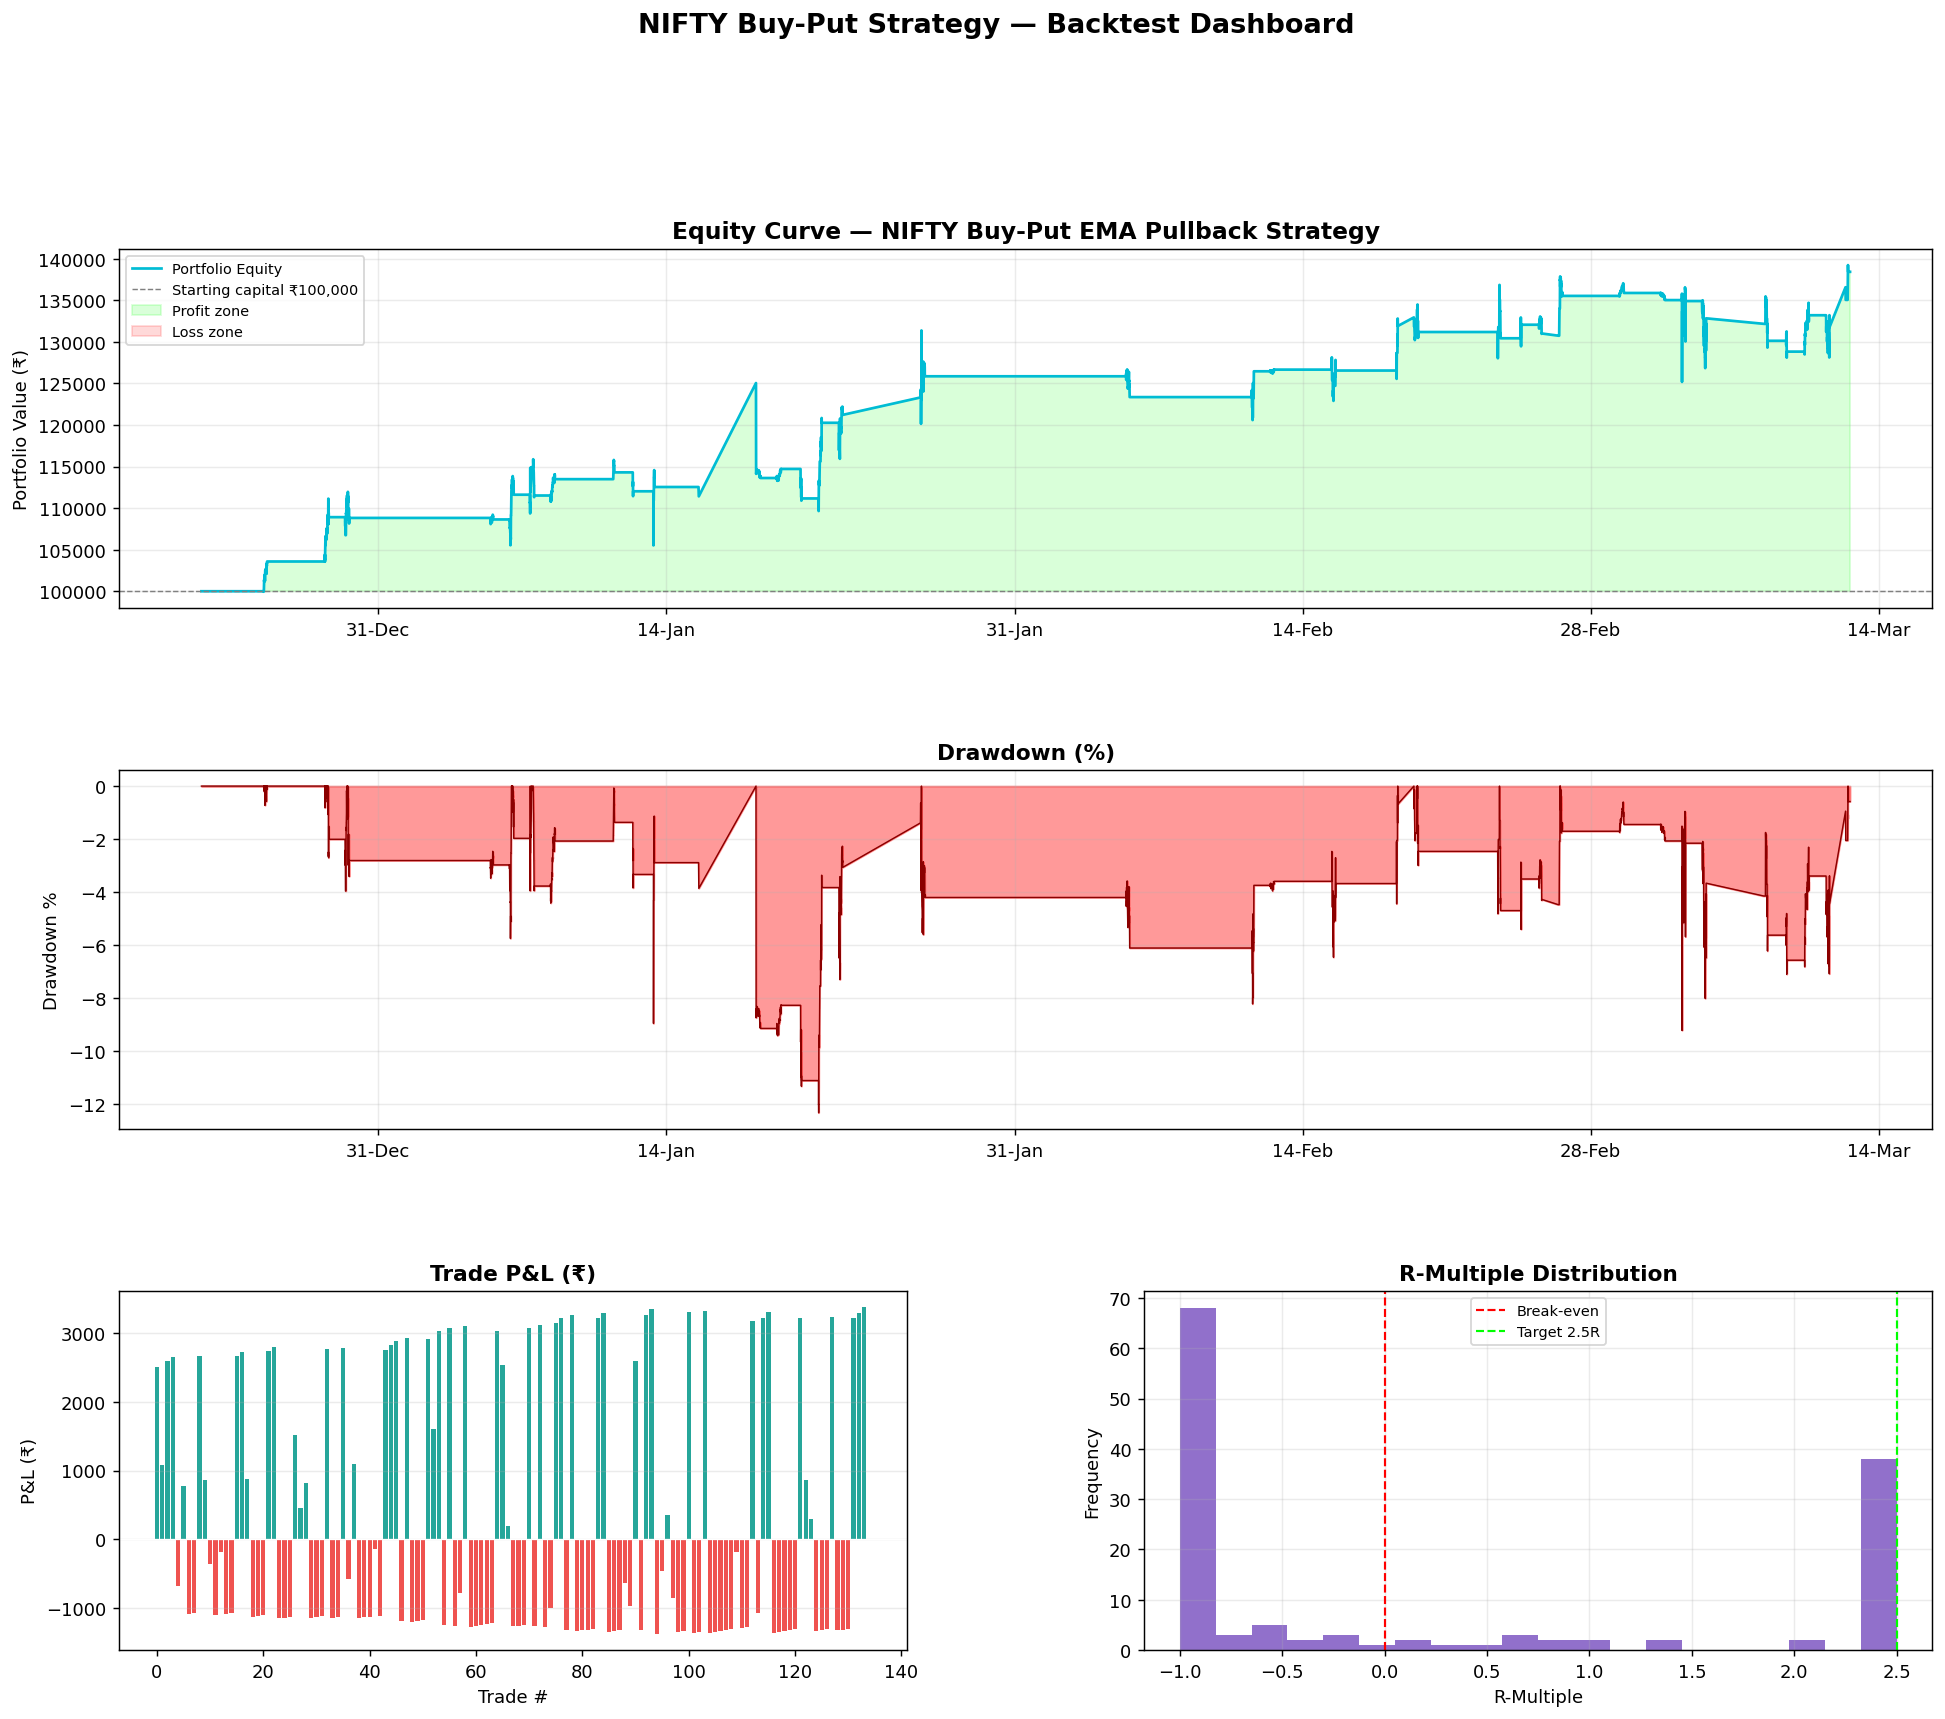

✅ Charts rendered.


In [50]:
# ============================================================
# CELL 7 — PERFORMANCE REPORT
# Win rate, PnL, Max Drawdown, Sharpe, Equity Curve
# ============================================================

def performance_report(trades_df: pd.DataFrame,
                        equity_df: pd.DataFrame,
                        capital:   float = CAPITAL) -> dict:
    """Print institutional-quality performance metrics."""

    if trades_df.empty:
        print("⚠️  No trades found in backtest period.")
        return {}

    t = trades_df.copy()

    # ── Core Stats ───────────────────────────────────────────
    total_trades  = len(t)
    wins          = (t["result"] == "WIN").sum()
    losses        = (t["result"] == "LOSS").sum()
    win_rate      = wins / total_trades * 100

    gross_profit  = t.loc[t["pnl_₹"] > 0, "pnl_₹"].sum()
    gross_loss    = t.loc[t["pnl_₹"] < 0, "pnl_₹"].sum()
    net_pnl       = t["pnl_₹"].sum()
    profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else np.inf

    avg_win       = t.loc[t["pnl_₹"] > 0, "pnl_₹"].mean() if wins > 0 else 0
    avg_loss      = t.loc[t["pnl_₹"] < 0, "pnl_₹"].mean() if losses > 0 else 0
    avg_r         = t["r_multiple"].mean()
    best_trade    = t["pnl_₹"].max()
    worst_trade   = t["pnl_₹"].min()

    # ── Max Drawdown ─────────────────────────────────────────
    eq = equity_df["equity"]
    rolling_max  = eq.cummax()
    drawdown_ser = (eq - rolling_max) / rolling_max * 100
    max_dd       = drawdown_ser.min()          # most negative value

    # ── Final equity & return ────────────────────────────────
    final_equity  = t["capital"].iloc[-1]
    total_return  = (final_equity - capital) / capital * 100

    # ── Exit reason breakdown ─────────────────────────────────
    exit_breakdown = t["exit_reason"].value_counts().to_dict()

    # ── Print report ─────────────────────────────────────────
    sep = "─" * 52
    print(f"\n{'═'*52}")
    print(f"  NIFTY BUY PUT STRATEGY — BACKTEST PERFORMANCE REPORT ")
    print(f"{'═'*52}")
    print(f"\n  {sep}")
    print(f"  {'TRADE STATISTICS':^50}")
    print(f"  {sep}")
    print(f"  Total Trades      : {total_trades}")
    print(f"  Wins / Losses     : {wins} / {losses}")
    print(f"  Win Rate          : {win_rate:.1f}%")
    print(f"  Avg R-Multiple    : {avg_r:.2f}R")
    print(f"  Profit Factor     : {profit_factor:.2f}")
    print(f"\n  {sep}")
    print(f"  {'P&L SUMMARY':^50}")
    print(f"  {sep}")
    print(f"  Gross Profit      : ₹{gross_profit:,.0f}")
    print(f"  Gross Loss        : ₹{gross_loss:,.0f}")
    print(f"  Net PnL           : ₹{net_pnl:,.0f}")
    print(f"  Total Return      : {total_return:.2f}%")
    print(f"  Avg Win / Avg Loss: ₹{avg_win:,.0f} / ₹{avg_loss:,.0f}")
    print(f"  Best Trade        : ₹{best_trade:,.0f}")
    print(f"  Worst Trade       : ₹{worst_trade:,.0f}")
    print(f"\n  {sep}")
    print(f"  {'RISK METRICS':^50}")
    print(f"  {sep}")
    print(f"  Starting Capital  : ₹{capital:,.0f}")
    print(f"  Ending Capital    : ₹{final_equity:,.0f}")
    print(f"  Max Drawdown      : {max_dd:.2f}%")
    print(f"\n  {sep}")
    print(f"  {'EXIT BREAKDOWN':^50}")
    print(f"  {sep}")
    for reason, cnt in exit_breakdown.items():
        print(f"  {reason:<18}: {cnt}")
    print(f"{'═'*52}\n")

    return {
        "total_trades" : total_trades, "win_rate_%"  : round(win_rate, 1),
        "net_pnl_₹"   : round(net_pnl, 2), "profit_factor": round(profit_factor, 2),
        "max_dd_%"     : round(max_dd, 2), "total_return_%": round(total_return, 2),
    }


def plot_results(trades_df: pd.DataFrame, equity_df: pd.DataFrame,
                 df: pd.DataFrame) -> None:
    """Plot equity curve, drawdown, and trade distribution."""
    if trades_df.empty:
        print("⚠️  No trades to plot.")
        return

    fig = plt.figure(figsize=(18, 14))
    gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

    # ── 1. Equity Curve ───────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(equity_df.index, equity_df["equity"],
             color="#00bcd4", linewidth=1.5, label="Portfolio Equity")
    ax1.axhline(CAPITAL, color="grey", linewidth=0.8, linestyle="--",
                label=f"Starting capital ₹{CAPITAL:,}")
    ax1.fill_between(equity_df.index, equity_df["equity"], CAPITAL,
                     where=equity_df["equity"] >= CAPITAL,
                     alpha=0.15, color="lime", label="Profit zone")
    ax1.fill_between(equity_df.index, equity_df["equity"], CAPITAL,
                     where=equity_df["equity"] < CAPITAL,
                     alpha=0.15, color="red",  label="Loss zone")
    ax1.set_title("Equity Curve — NIFTY Buy-Put EMA Pullback Strategy",
                  fontsize=13, fontweight="bold")
    ax1.set_ylabel("Portfolio Value (₹)")
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.25)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))

    # ── 2. Max Drawdown ───────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    roll_max = equity_df["equity"].cummax()
    dd = (equity_df["equity"] - roll_max) / roll_max * 100
    ax2.fill_between(dd.index, dd, 0, color="red", alpha=0.4)
    ax2.plot(dd.index, dd, color="darkred", linewidth=0.8)
    ax2.set_title("Drawdown (%)", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Drawdown %")
    ax2.grid(alpha=0.25)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))

    # ── 3. PnL Distribution ───────────────────────────────────
    ax3 = fig.add_subplot(gs[2, 0])
    colors_bar = ["#26a69a" if x > 0 else "#ef5350"
                  for x in trades_df["pnl_₹"]]
    ax3.bar(range(len(trades_df)), trades_df["pnl_₹"],
            color=colors_bar, edgecolor="none")
    ax3.axhline(0, color="white", linewidth=0.7)
    ax3.set_title("Trade P&L (₹)", fontsize=12, fontweight="bold")
    ax3.set_xlabel("Trade #")
    ax3.set_ylabel("P&L (₹)")
    ax3.grid(alpha=0.25, axis="y")

    # ── 4. R-Multiple Histogram ───────────────────────────────
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.hist(trades_df["r_multiple"], bins=20,
             color="#7e57c2", edgecolor="none", alpha=0.85)
    ax4.axvline(0, color="red",  linewidth=1.2, linestyle="--", label="Break-even")
    ax4.axvline(RISK_REWARD, color="lime", linewidth=1.2,
                linestyle="--", label=f"Target {RISK_REWARD}R")
    ax4.set_title("R-Multiple Distribution", fontsize=12, fontweight="bold")
    ax4.set_xlabel("R-Multiple")
    ax4.set_ylabel("Frequency")
    ax4.legend(fontsize=8)
    ax4.grid(alpha=0.25)

    plt.suptitle("NIFTY Buy-Put Strategy — Backtest Dashboard",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    print("✅ Charts rendered.")


# ── Run ──────────────────────────────────────────────────────
required_vars = ["trades_df", "equity_df", "signal_df"]
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print("⚠️ Missing required dataframes:", ", ".join(missing_vars))
    print("Run the previous backtest/output cell first to generate them.")
else:
    stats = performance_report(trades_df, equity_df)
    plot_results(trades_df, equity_df, signal_df)


In [51]:
if not trades_df.empty:
    csv_path =   "/content/trades.csv"
    trades_df.to_csv(csv_path, index=False)
    print(f"✅ trades.csv saved  →  {csv_path}")
else:
    print("⚠️  No trades to save.")

✅ trades.csv saved  →  /content/trades.csv
